In [1]:
#imported from Pranav Sanghavi's notebook -- 
import glob 
import os
import time
import h5py
import matplotlib.pylab as plt
import numpy as np
import numpy.ma as ma
from matplotlib.offsetbox import AnchoredText
from matplotlib.pylab import colorbar 
from skrf import Network, Frequency
from platform import python_version
from rawice import *
import math
import psutil
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
#importing for Will's function --  
from scipy import interpolate
import datetime
from scipy.signal import square
from scipy.stats import pearsonr
import pandas
import time_utils as tu
from mpl_toolkits.axes_grid1 import make_axes_locatable

style = 'fast'
tick_dir = 'in'
plt.style.use(style)
plt.rcParams['xtick.direction'] = tick_dir
plt.rcParams['ytick.direction'] = tick_dir
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['font.size'] = 15
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif"})

###################################################################################
# Analog chain labels
###################################################################################

#pathtoacfile = "/home/observer/tone_jupyter/anachainz.csv"
#ac = np.genfromtxt(pathtoacfile, delimiter=",", names=True,
#                   dtype=(int, int, 'U5', 'U5', int, 'U2', int))
#inputs = ac['feed']

def get_beam_fwhm(d=6.0, nu=600):
    fwhm = constants.c/(nu*1e6)/d   # lambda/D
    return np.rad2deg(fwhm * 1.22)

def gaussian(x, a, mean, sigma):
    val = a * np.exp(-(x - mean)**2 / sigma**2)
    return val

def scale_zero_one(x):
    return (x - x.min())/(x.max() - x.min())

def seconds_to_degrees(seconds, declination=22.0145):
    """
        This function converts seconds to degrees of sky motion at a latitude 
        default TONE latitude -- default for crab.
    """
    return seconds * np.cos(np.deg2rad(declination)) / 240

def read_corr_mode_h5(file_path, f_start=None, f_stop=None):
    """
        This function reads all hdf5 files.
    """
    class correlator_data:
        def __init__(self, vis, time, sat, index_map):
            self.vis = vis
            self.time = time
            self.sat = sat
            self.freq = index_map["freq"][:]
            self.prod = index_map['prod'][:]
    files = glob.glob(file_path + "*[!.lock]")
    files.sort()
    
    #grab different sets of files.  
    if f_start is not None:
        if f_stop is not None:
            files = files[f_start:f_stop]
        else:
            files = files[f_start:]
    if f_start is None:
        if f_stop is not None:
            files = files[:f_stop]

    try:
        t = 0
        for x in files:
            print(f"Reading File: {x}")
            f = h5py.File(x, "r")
            index_map = f['index_map']
            if(t == 0):
                vis = f['vis'][:]
                time = index_map['time'][:]
                sat = f['sat'][:]
                print("Appended vis data and time stream from %s" % (x))
                t = t + 1
            else:
                time = np.append(time, index_map['time'][:])
                vis = np.append(vis, f['vis'][:], axis=0)
                sat = np.append(sat, f['sat'][:], axis=0)
                print("Appended vis data and time stream from %s" % (x))
        
        return correlator_data(
            vis,
            time,
            sat,
            index_map
        )
    finally:
        print("Done!!!!!!!")

def get_mag_phase(corr_dat):
    """
        This function returns magnitude and phase in degrees of correlations.
    """
    return np.absolute(corr_dat), np.rad2deg(np.angle(corr_dat))

def plot_waterfall_corr_data(data, corr_indices):
    """
        This function plots waterfall across 1024 frequency channels.
        Frequency range: 400-800MHz
    """
    fig=plt.figure(figsize=(20,15))
    dim1 = math.floor(math.sqrt(len(corr_indices)))
    dim2 = math.ceil(len(corr_indices)/dim1)
    for i,auto in enumerate(corr_indices):
        ax=plt.subplot(dim1, dim2, i + 1)
        wfall = data[:, :, auto] # auto -> corr index 
        im=plt.imshow(wfall, vmin = np.nanpercentile(wfall,5), vmax =np.nanpercentile(wfall,95), cmap='gnuplot2', aspect='auto')
        plt.xlabel("freq index")
        plt.ylabel("time index")
        plt.title(f"corr {corr_data.prod[auto]}")
        divider=make_axes_locatable(ax)
        cax=divider.append_axes("right", size="5%", pad=0.05)
        cbar=fig.colorbar(im,cax=cax)
        cbar.set_label('Power [$ADU^2$]')
    plt.tight_layout()
    
def plot_freq_channel_corr_data(pow_mag, freq_index, freq, corr_indices):
    """
        This function plots phase for a given frequency index for given time window.
    """
    plt.figure(figsize=(20, 20))
    dim1 = math.floor(math.sqrt(len(corr_indices)))
    dim2 = math.ceil(len(corr_indices)/dim1)
    for index, corr_index in enumerate(corr_indices):
            plt.subplot(dim1, dim2, index + 1)
            plt.title(f"Corr: {corr_data.prod[corr_index]}")
            plt.plot(pow_mag[:, freq_index, corr_index])
    plt.suptitle(f"Frequency {freq} MHz")
    plt.tight_layout()
    
def plot_phase_corr_data(pow_phase, corr_indices, t_ind_arr):
    """
        This function plots phase for a given time index across frequency range of 400-800MHz.
    """
    colorsarr=cm.gnuplot2(np.linspace(0,1,2048))
    for i, t_index in enumerate(t_ind_arr):
        fig= plt.figure(figsize=(25, 10))
        dim1 = math.floor(math.sqrt(len(corr_indices)*len(t_ind_arr)))
        dim2 = math.ceil(len(corr_indices)*len(t_ind_arr)/dim1)
        for index, corr_index in enumerate(corr_indices):
                ax = plt.subplot(dim2, dim1, i + 1)
                ax.plot(pow_phase[t_index,:, corr_index], c=colorsarr[300], label=f'time index {t_index}')
                ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
                plt.xlabel(f"frequency index")
                plt.ylabel(f"phase (degrees)")
                plt.title(f"Corr: {corr_data.prod[corr_index]}")
                #plt.suptitle(f"Correlated noise phase")
        plt.tight_layout()


In [2]:
print("current python version is:",python_version())
print("current numpy version is:",np.__version__)

current python version is: 3.9.10
current numpy version is: 1.22.4


['acquisition_name', 'archive_version', 'collection_server', 'git_version_tag', 'instrument_name', 'notes', 'system_user', 'type', 'version']
20250319T171034Z_WVUc52_digitalgain
3.2.0
weathertop
heads/kmb/gbo_outrigger-0-gc2e502f0-dirty
WVUc52

wvurail
<class 'pychfpga.digital_gain.DigitalGainArchive'>
0.5
[('compute_time', <HDF5 dataset "compute_time": shape (1, 16), type "<f8">), ('gain_coeff', <HDF5 dataset "gain_coeff": shape (1, 1024, 16), type "<c8">), ('gain_exp', <HDF5 dataset "gain_exp": shape (1, 16), type "<i4">), ('index_map', <HDF5 group "/index_map" (3 members)>), ('update_id', <HDF5 dataset "update_id": shape (1,), type "|O">)]
<HDF5 dataset "compute_time": shape (1, 16), type "<f8">
<HDF5 group "/index_map" (3 members)>
<HDF5 dataset "gain_coeff": shape (1, 1024, 16), type "<c8">
<HDF5 dataset "gain_exp": shape (1, 16), type "<i4">
Calculating digital gains of the channels...


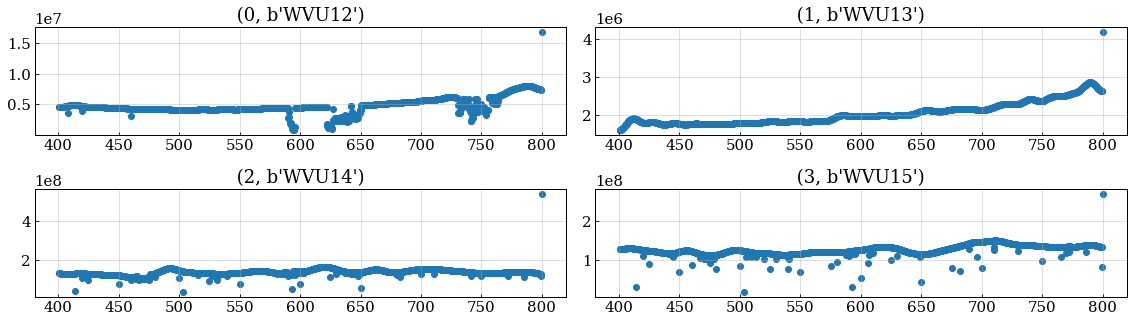

In [3]:
"""
    Reading digital gains for all the correlator channels 
"""

f = h5py.File("/Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/digital_gains/20250319T171034Z_WVUc52_digitalgain/00000057.h5","r")

#Plotting digital gains -- 
print(list(f.attrs))
print(f.attrs['acquisition_name'])
print(f.attrs['archive_version'])
print(f.attrs['collection_server'])
print(f.attrs['git_version_tag'])
print(f.attrs['instrument_name'])
print(f.attrs['notes'])
print(f.attrs['system_user'])
print(f.attrs['type'])
print(f.attrs['version'])

print(list(f.items()))
print((f['compute_time']))
print((f['index_map']))
print((f['gain_coeff']))
print((f['gain_exp']))

inputs = (f['index_map']['input'][:])
frqs = f['index_map']['freq'][:]
gaincoeff = f['gain_coeff'][()]
gainexp = f['gain_exp'][()]
gain = gaincoeff.real*np.exp2(gainexp)

plt.figure(figsize=[16,18])
print(f"Calculating digital gains of the channels...")
i = 0
for i in np.arange(0,4,1):  
    plt.subplot(8,2,i+1)
    #Digital gain of every channel
    plt.scatter(frqs['centre'], gain[0][:,i]) # i referes to input channel (total 16 ch on iceboard); 
    #plt.title( " %s and gain_exp = %s and rms %s for rms i/p %s" %(inputs[i], gainexp[:,i], rms[i][2], rms[i][0][2]))
    plt.title( " %s " %(inputs[i]))
plt.tight_layout()

## Analysis of correlator data for correlation powers, waterfall and phase

In [4]:
file_path = '/Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250319T171034Z_WVUc52/corr/*/*' 

corr_data75p = read_corr_mode_h5(file_path, f_start=229, f_stop=232)
print("getting auto and cross-correlation magnitudes and phase")
pow_mag75p, pow_phase75p = get_mag_phase(corr_data75p.vis)
print("done getting pow_mag and pow_phase")
corr_size75p=corr_data75p.vis[:,:,:].shape
print('corr data shape: {}'.format(corr_size75p)) # time bins - freq bins - corr indices


corr_data100p = read_corr_mode_h5(file_path, f_start=254, f_stop=257)
print("getting auto and cross-correlation magnitudes and phase")
pow_mag100p, pow_phase100p = get_mag_phase(corr_data100p.vis)
print("done getting pow_mag and pow_phase")
corr_size100p=corr_data100p.vis[:,:,:].shape
print('corr data shape: {}'.format(corr_size100p)) # time bins - freq bins - corr indices

corr_data115p = read_corr_mode_h5(file_path, f_start=269, f_stop=272)
print("getting auto and cross-correlation magnitudes and phase")
pow_mag115p, pow_phase115p = get_mag_phase(corr_data115p.vis)
print("done getting pow_mag and pow_phase")
corr_size115p=corr_data115p.vis[:,:,:].shape
print('corr data shape: {}'.format(corr_size115p)) # time bins - freq bins - corr indices

corr_data130p = read_corr_mode_h5(file_path, f_start=284, f_stop=287)
print("getting auto and cross-correlation magnitudes and phase")
pow_mag130p, pow_phase130p = get_mag_phase(corr_data130p.vis)
print("done getting pow_mag and pow_phase")
corr_size130p=corr_data130p.vis[:,:,:].shape
print('corr data shape: {}'.format(corr_size130p)) # time bins - freq bins - corr indices


corr_data135p = read_corr_mode_h5(file_path, f_start=289, f_stop=292)
print("getting auto and cross-correlation magnitudes and phase")
pow_mag135p, pow_phase135p = get_mag_phase(corr_data135p.vis)
print("done getting pow_mag and pow_phase")
corr_size135p=corr_data135p.vis[:,:,:].shape
print('corr data shape: {}'.format(corr_size135p)) # time bins - freq bins - corr indices



Reading File: /Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250319T171034Z_WVUc52/corr/20250319T171131Z/0229
Appended vis data and time stream from /Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250319T171034Z_WVUc52/corr/20250319T171131Z/0229
Reading File: /Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250319T171034Z_WVUc52/corr/20250319T171131Z/0230
Appended vis data and time stream from /Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250319T171034Z_WVUc52/corr/20250319T171131Z/0230
Reading File: /Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250319T171034Z_WVUc52/corr/20250319T171131Z/0231
Appended vis data and time stream from /Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_ra

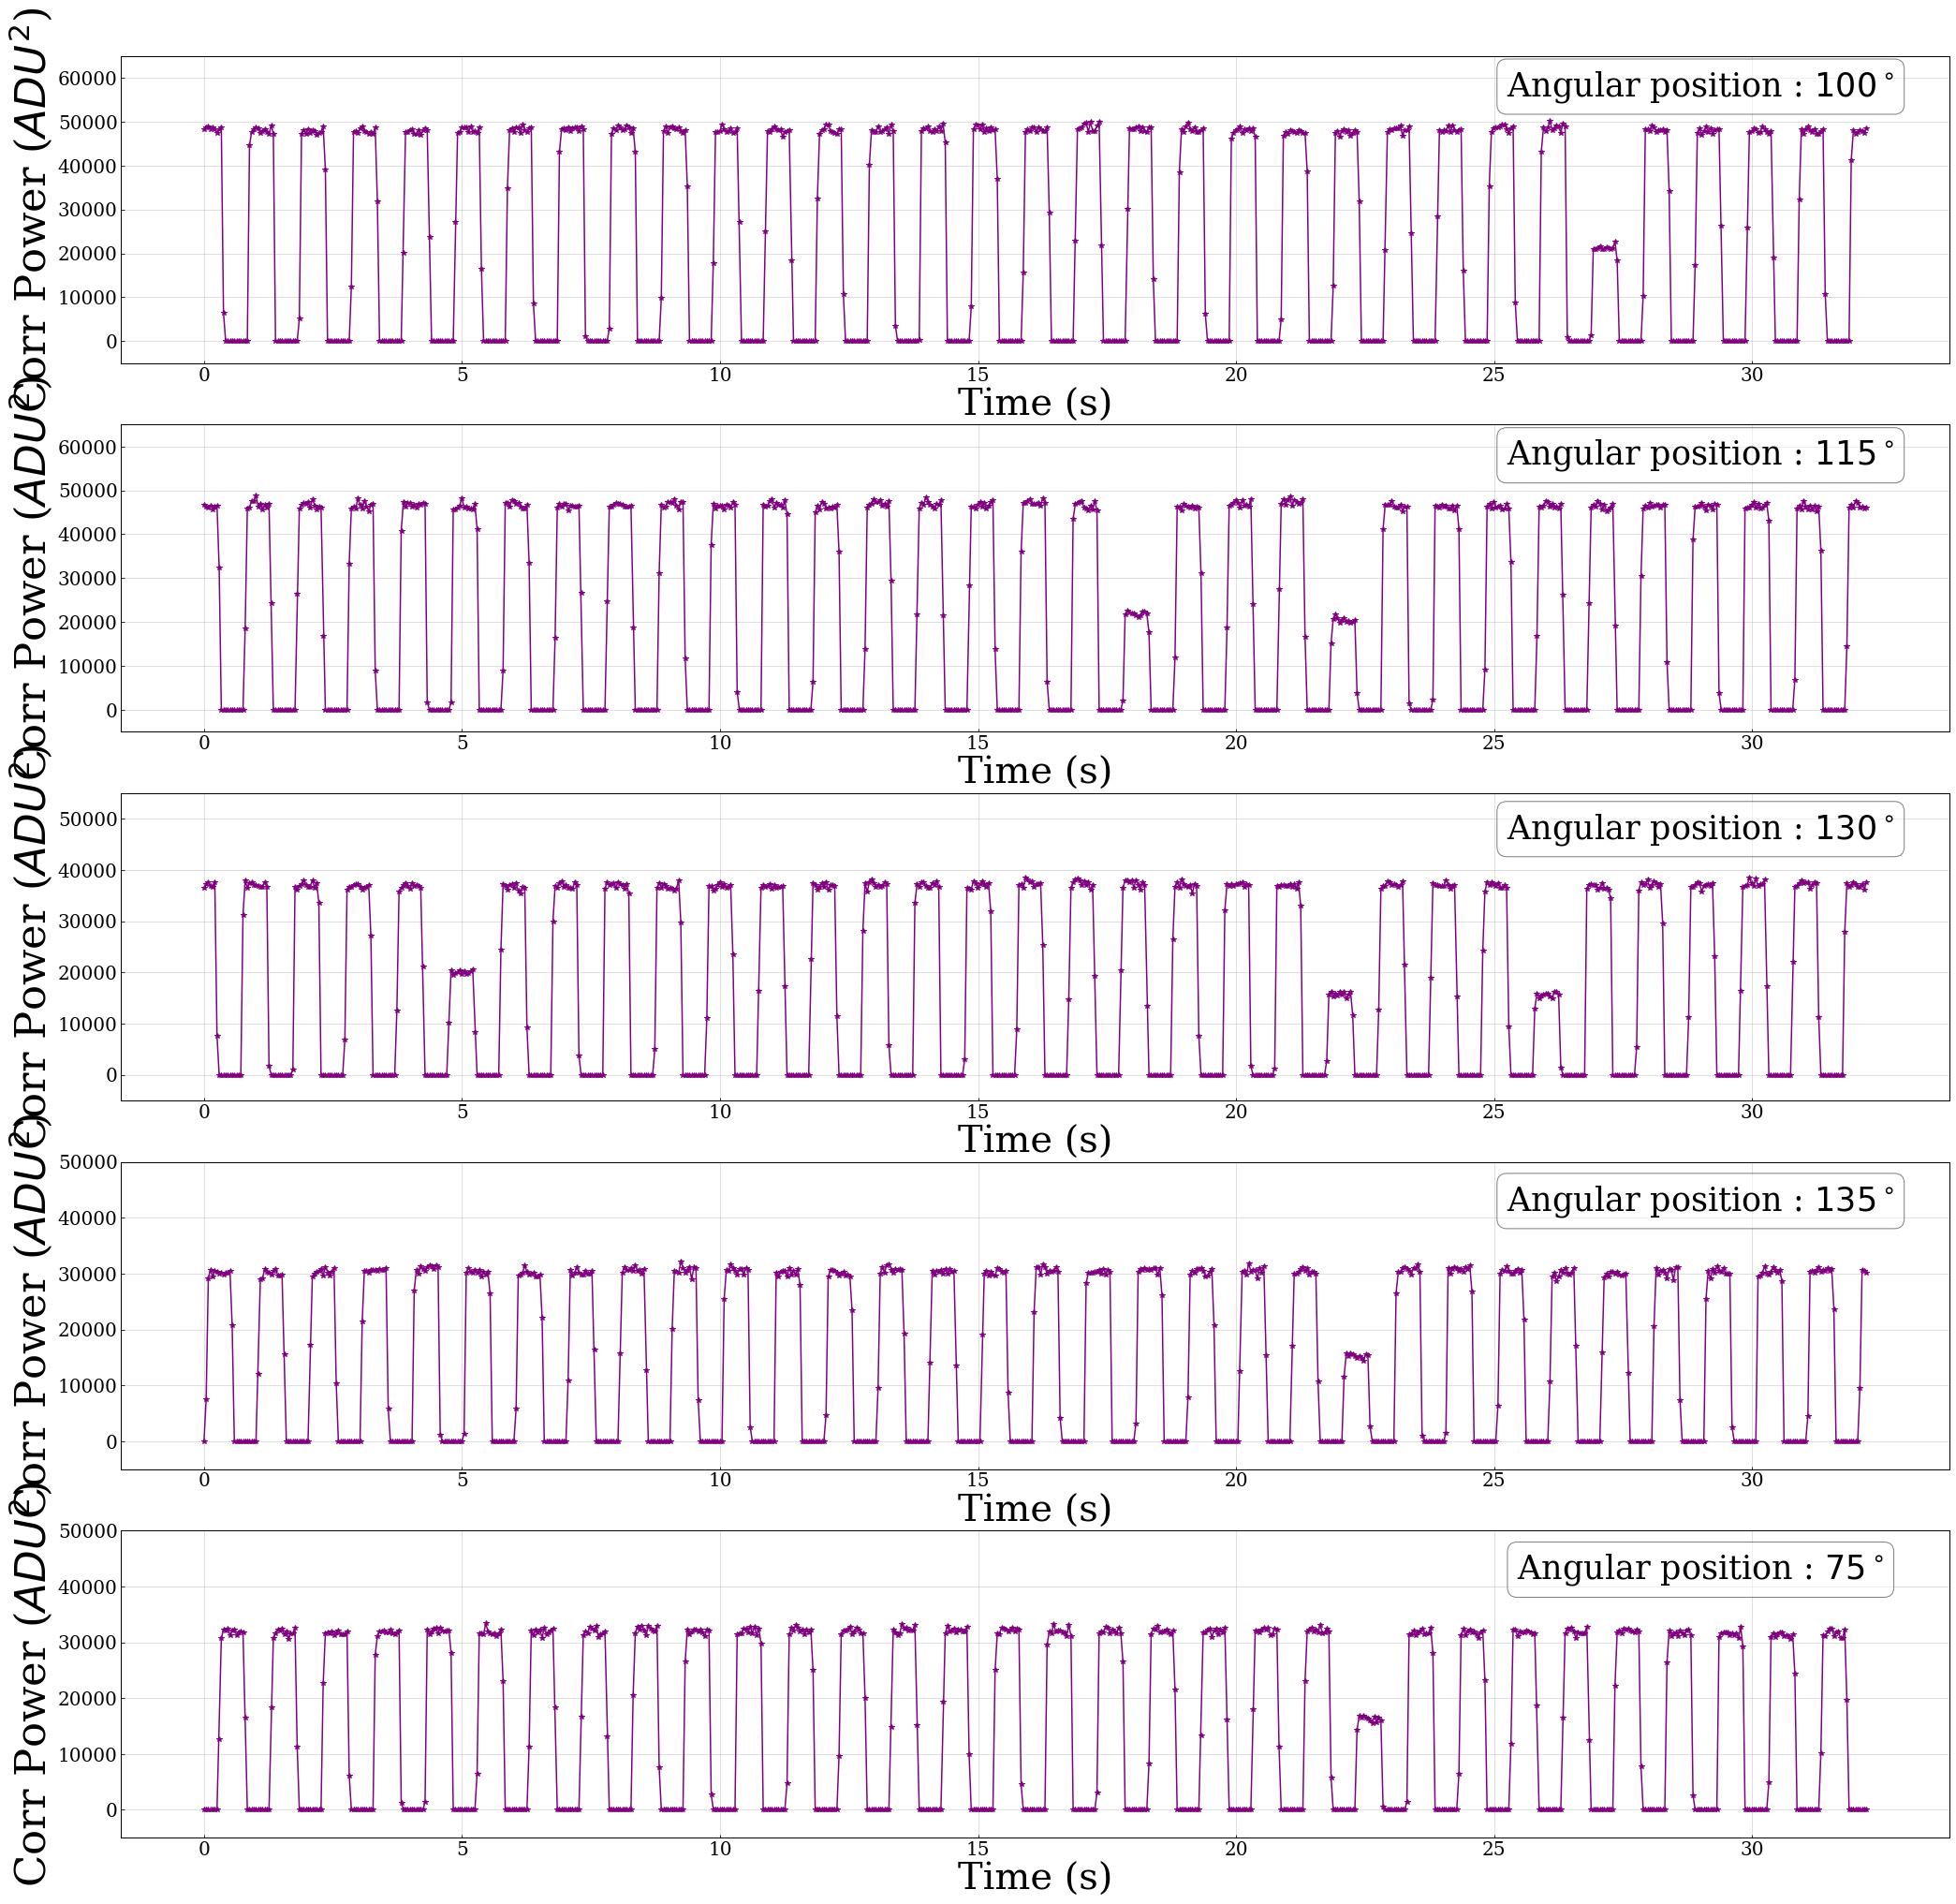

In [5]:
corr_size100p=corr_data100p.vis[:,:,:].shape
delta_time = np.diff(corr_data100p.time["irigb_time"])[1]*1e-9

tmin,tmax=[0,corr_size100p[0]] #time in t-indices
xtime=np.linspace(0,delta_time*tmax, tmax) # time in seconds 
f_ind=850
corr_index=1
    
colorsarr=cm.gnuplot2(np.linspace(0,1,1024))
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5, 1, figsize=(35, 35))
freq=400+((1024-f_ind)*0.390625)

ax1.plot(xtime,pow_mag100p[tmin:tmax,f_ind,corr_index], marker="*", c='purple')
ax1.text(29, 58000, r"Angular position : $100^\circ$", ha='center', va='center', fontsize=35, bbox=dict(boxstyle='round', facecolor='white', 
        edgecolor='black', alpha=0.5))
ax1.set_xlabel("Time (s)", fontsize=40)
ax1.set_ylabel(r"Corr Power ($ADU^2$)", fontsize=45)
ax1.tick_params(axis='both', which='major', labelsize=20)
ax1.set_ylim(-5000,65000)
ax2.plot(xtime,pow_mag115p[tmin:tmax,f_ind,corr_index], marker="*", c='purple')
ax2.text(29, 58000, r"Angular position : $115^\circ$", ha='center', va='center', fontsize=35, bbox=dict(boxstyle='round', facecolor='white', 
        edgecolor='black', alpha=0.5))
ax2.set_xlabel("Time (s)", fontsize=40)
ax2.set_ylabel(r"Corr Power ($ADU^2$)", fontsize=45)
ax2.tick_params(axis='both', which='major', labelsize=20)
ax2.set_ylim(-5000,65000)
ax3.plot(xtime,pow_mag130p[tmin:tmax,f_ind,corr_index], marker="*", c='purple')
ax3.text(29, 48000, r"Angular position : $130^\circ$", ha='center', va='center', fontsize=35, bbox=dict(boxstyle='round', facecolor='white', 
        edgecolor='black', alpha=0.5))
ax3.set_xlabel("Time (s)", fontsize=40)
ax3.set_ylabel(r"Corr Power ($ADU^2$)", fontsize=45)
ax3.tick_params(axis='both', which='major', labelsize=20)
ax3.set_ylim(-5000,55000)

ax4.plot(xtime,pow_mag135p[tmin:tmax,f_ind,corr_index], marker="*", c='purple')
ax4.text(29,43000, r"Angular position : $135^\circ$", ha='center', va='center', fontsize=35, bbox=dict(boxstyle='round', facecolor='white',
        edgecolor='black', alpha=0.5))
ax4.set_xlabel("Time (s)", fontsize=40)
ax4.set_ylabel(r"Corr Power ($ADU^2$)", fontsize=45)
ax4.tick_params(axis='both', which='major', labelsize=20)
ax4.set_ylim(-5000,50000)

ax5.plot(xtime,pow_mag75p[tmin:tmax,f_ind,corr_index], marker="*", c='purple')
ax5.text(29,43000, r"Angular position : $75^\circ$", ha='center', va='center', fontsize=35, bbox=dict(boxstyle='round', facecolor='white',
        edgecolor='black', alpha=0.5))
ax5.set_xlabel("Time (s)", fontsize=40)
ax5.set_ylabel(r"Corr Power ($ADU^2$)", fontsize=45)
ax5.tick_params(axis='both', which='major', labelsize=20)
ax5.set_ylim(-5000,50000)




plt.show()
plt.tight_layout()

#fig.savefig('/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/publication_figures/chamber_corr_powers_glitches_higherangles.pdf', 
#            dpi=300)

In [2]:
#Reading correlation files -- 
file_path = '/Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250312T171036Z_WVUc52/corr/*/*' 

corr_data = read_corr_mode_h5(file_path, f_start=17, f_stop=19) 
print("getting auto and cross-correlation magnitudes and phase")
pow_mag, pow_phase = get_mag_phase(corr_data.vis)
print("done getting pow_mag and pow_phase")
sat_data = corr_data.sat.real

corr_size=corr_data.vis[:,:,:].shape
print('corr data shape: {}'.format(corr_size)) # time bins - freq bins - corr indices

Reading File: /Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250312T171036Z_WVUc52/corr/20250312T171133Z/0017
Appended vis data and time stream from /Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250312T171036Z_WVUc52/corr/20250312T171133Z/0017
Reading File: /Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250312T171036Z_WVUc52/corr/20250312T171133Z/0018
Appended vis data and time stream from /Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250312T171036Z_WVUc52/corr/20250312T171133Z/0018
Done!!!!!!!
getting auto and cross-correlation magnitudes and phase
done getting pow_mag and pow_phase
corr data shape: (512, 1024, 10)


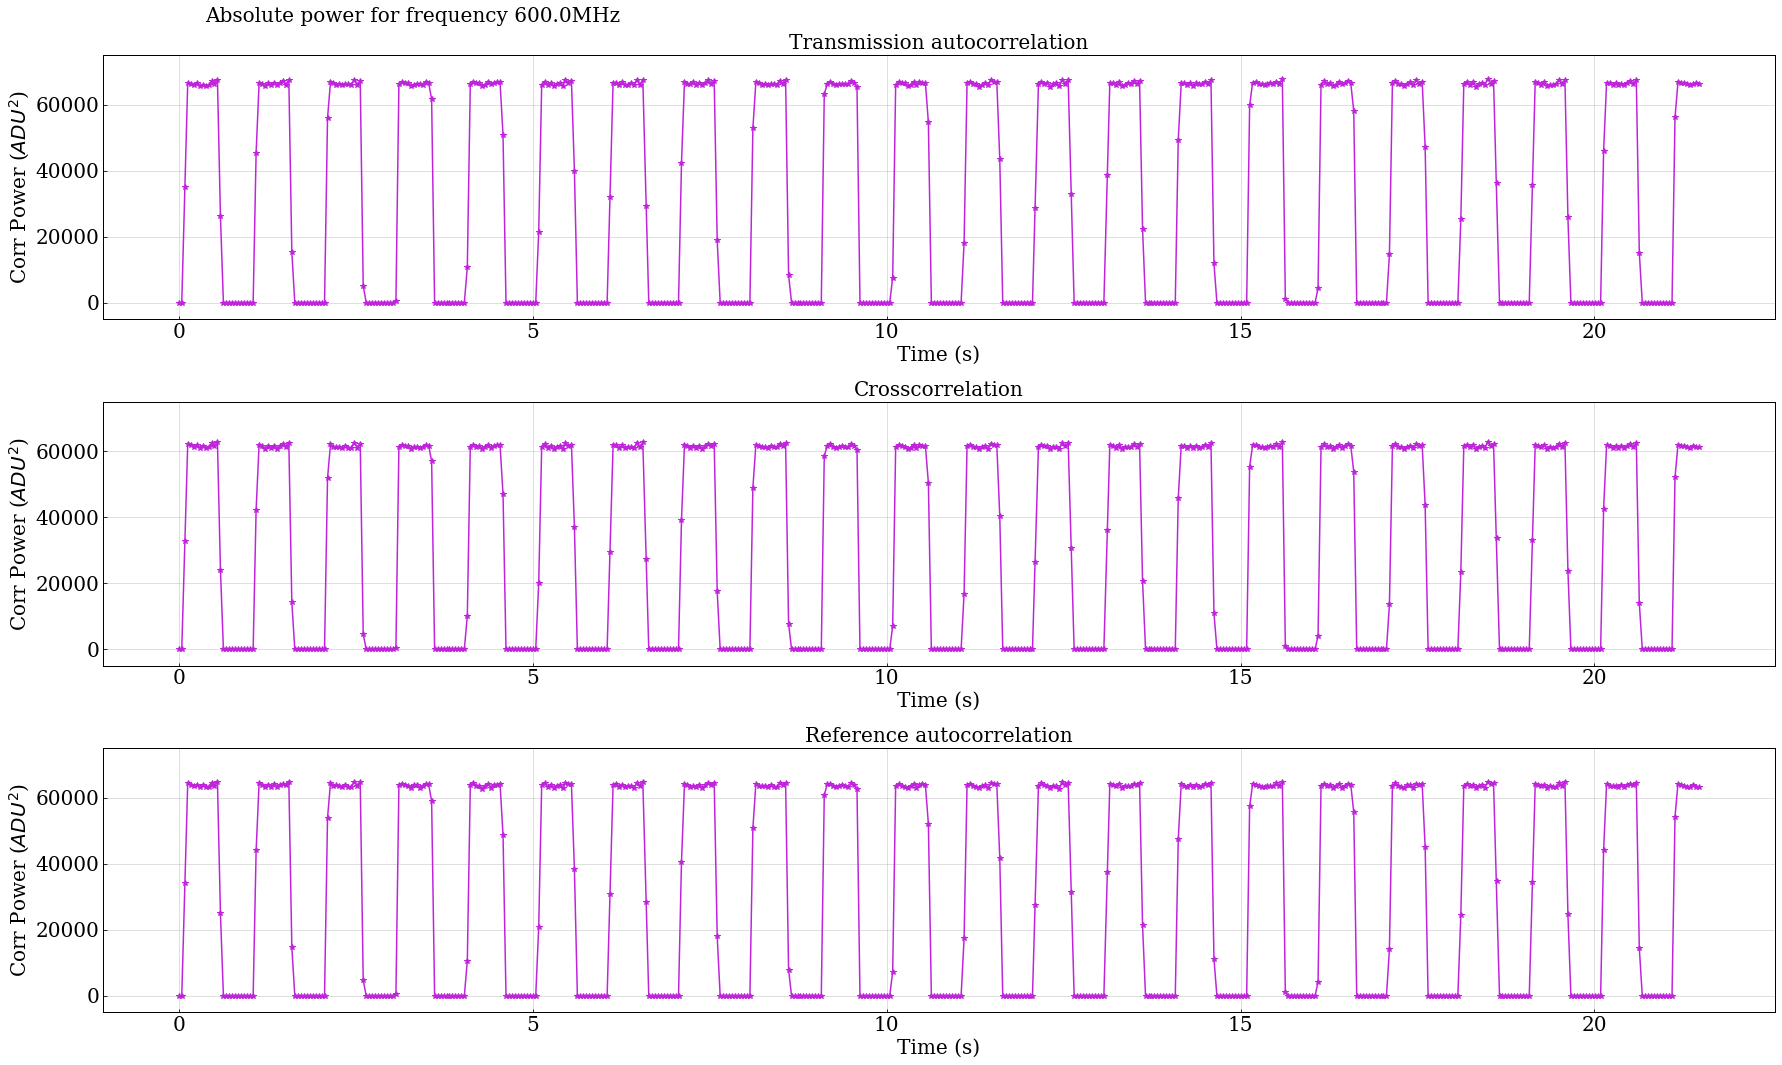

In [4]:
#Plotting correlation powers against time index for a given set of frequencies -- 
delta_time = np.diff(corr_data.time["irigb_time"])[1]*1e-9
tmin,tmax=[0,corr_size[0]]
xtime=np.linspace(0,delta_time*tmax, tmax) # time in seconds 
freq_arr=[512]
corr_indices=[0,1,4]

fig, axes = plt.subplots(3, 1, figsize=(25, 15))
for f_ind in freq_arr:
    colorsarr=cm.gnuplot2(np.linspace(0,1,2048))
    freq=400+((1024-f_ind)*0.390625)
    for index2, corr_index in enumerate(corr_indices): 
        ax=axes[index2]
        ax.plot(xtime,pow_mag[tmin:tmax,f_ind,corr_index], marker="*", c=colorsarr[1000])
        ax.set_ylim(-5000,75000)
        #ax.set_xlim(0,delta_time*tmax-15)
        ax.tick_params(axis='both', which='major', labelsize=20)
        ax.set_xlabel("Time (s)", fontsize=20)
        ax.set_ylabel(r"Corr Power ($ADU^2$)", fontsize=20)
        if corr_index==0:
            ax.set_title(f"Transmission autocorrelation", fontsize=20)
        elif corr_index==1:
            ax.set_title(f"Crosscorrelation", fontsize=20)
        else:
            ax.set_title(f"Reference autocorrelation", fontsize=20)
    axes[0].text(3.3, 85000, f"Absolute power for frequency {freq}MHz", ha='center', fontsize=20)
fig.tight_layout()
#plt.savefig('/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/March12...036Z/publication_figures/abs_powersI.png', 
#            dpi=300)

plt.show()

In [8]:
"""
    function plotting waterfall (for publication purpose) -- otherwise use generic one defined in the first cell 
"""

def plot_waterfall_corr_data_pub(pow_mag, corr_indices):
    """
        This function plots waterfall across 1024 frequency channels.
        Frequency range: 400-800MHz
    """
    fig=plt.figure(figsize=(20,15))
    dim1 = math.floor(math.sqrt(len(corr_indices)))
    dim2 = math.ceil(len(corr_indices)/dim1)
    for i,corr_index in enumerate(corr_indices):
        ax=plt.subplot(dim1, dim2, i + 1)
        wfall = pow_mag[:, :, corr_index]
        wfall = wfall.T      # transposing wfall to swap axes 
        y_min, y_max = 400, 800        
        x_min, x_max = 21.47483648, 0   #y_min=delta_time*tmax (reversed y-axis)
        im=plt.imshow(wfall, vmin = np.nanpercentile(wfall,5), vmax =np.nanpercentile(wfall,95), 
                      cmap='gnuplot2', aspect='auto', extent=[x_max, x_min, y_max, y_min])
        #x1 = 721.875
        #ax.axvline(x=x1, color='red', linestyle='--', linewidth=2.5)
        y2 = 600
        ax.axhline(y=y2, color='red', linestyle='--', linewidth=2.5)
        #x3 = 487.5
        #ax.axvline(x=x3, color='red', linestyle='--', linewidth=2.5)
        #plt.text(
        #        x1, 20, f'Freq = {x1}', rotation=90, 
        #        ha='right', va='bottom', fontsize=15,
        #        color='r')
        x1 = 2.4
        ax.axvline(x=x1, color='black', linestyle='--', linewidth=2.5)
        x2 = 2.9
        ax.axvline(x=x2, color='white', linestyle='--', linewidth=2.5)
        ax.set_xlim(0, delta_time*tmax-15)
        ax.set_ylabel("Frequency (MHz)", fontsize=25)
        ax.set_xlabel("Time (s)", fontsize=25)
        ax.tick_params(axis='both', which='major', labelsize=20)
        if corr_index==0:
            ax.set_title(f"Transmission autocorrelation", fontsize=18)
        elif corr_index==1:
            ax.set_title(f"Crosscorrelation", fontsize=20)
        else:
            ax.set_title(f"Reference autocorrelation", fontsize=20)
        #plt.title(f"corr {corr_data.prod[auto]}")
        divider=make_axes_locatable(ax)
        cax=divider.append_axes("right", size="5%", pad=0.05)
        cbar=fig.colorbar(im,cax=cax)
        cbar.set_label('Corr Power [$ADU^2$]', fontsize=25)
        cbar.ax.tick_params(labelsize=20)
    plt.tight_layout()
    
#    fig.savefig('/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/March12...036Z/publication_figures/waterfallI.pdf', 
#            dpi=300)

/var/folders/g1/8y2gy6ys10d17y5j2rzwkwzc0000gn/T/ipykernel_46793/595788895.py:48: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cbar=fig.colorbar(im,cax=cax)


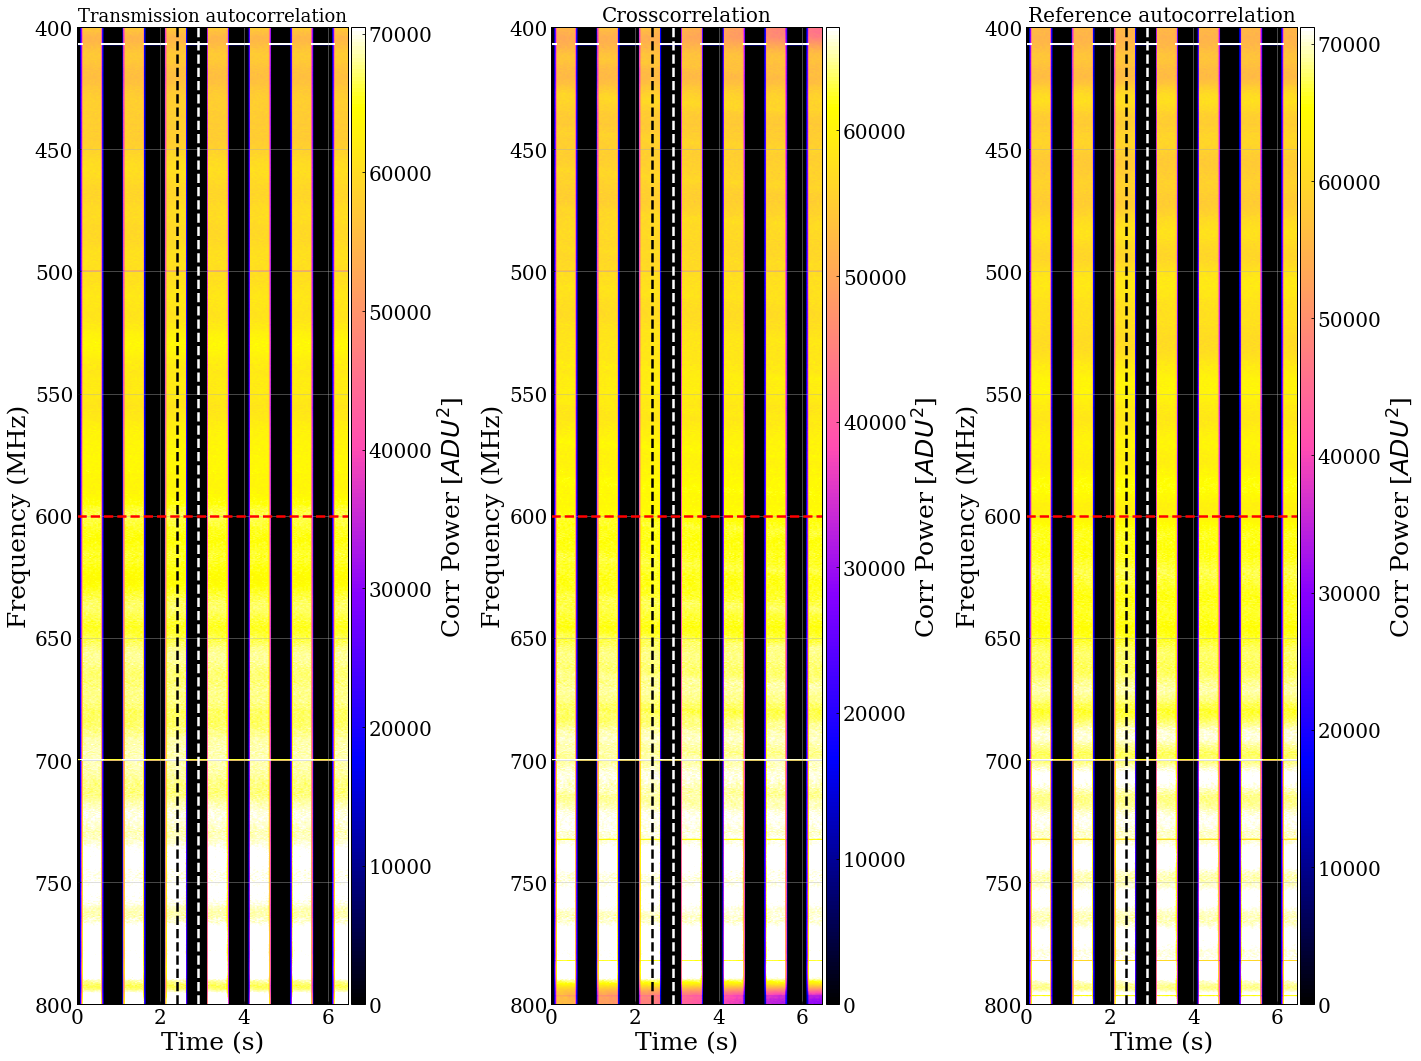

In [9]:
#Plotting waterfall for publication --

corr_indices=[0,1,4] 
plot_waterfall_corr_data_pub(pow_mag[:,:,:],corr_indices)

In [10]:
"""
    modified function plotting phase against frequency (for publication purpose) -- 
    otherwise use generic one defined in the first cell
"""

def plot_phase_corr_data_pub(pow_phase, corr_indices, t_ind_arr):
    """
        This function plots phase for a given time index across frequency range of 400-800MHz.
    """
    colorsarr=cm.gnuplot2(np.linspace(0,1,2048))
    for i, t_index in enumerate(t_ind_arr):
        fig= plt.figure(figsize=(10, 5))
        dim1 = math.floor(math.sqrt(len(corr_indices)*len(t_ind_arr)))
        dim2 = math.ceil(len(corr_indices)*len(t_ind_arr)/dim1)
        for index, corr_index in enumerate(corr_indices):
                ax = plt.subplot(dim2, dim1, i + 1)
                ax.plot(pow_phase[t_index,:, corr_index], c='black', label=f'time=2.4s')
                ax.set_xticks([0,200,400,600,800,1024],[800,721.875,643.75,565.625,487.5,400])
                ax.invert_xaxis()
                ax.set_ylim(-200,260)
                ax.legend(loc='upper right', bbox_to_anchor=(1, 1), fontsize=15)
                plt.xlabel(f"Frequency (MHz)", fontsize=20)
                plt.ylabel(f"Phase (degrees)", fontsize=20)
                #plt.title(f"Crosscorrelation Channel", fontsize=20)
                #plt.suptitle(f"Correlated noise phase")
        plt.tight_layout()
        #fig.savefig('/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/March12...036Z/publication_figures/phase_at2.4sec.png', 
        #    dpi=300)

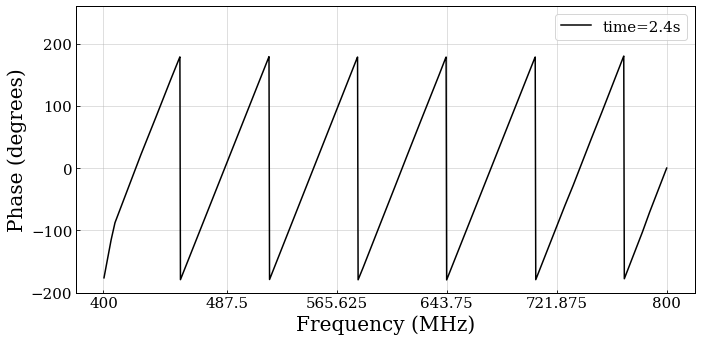

In [11]:
#Phase for a set of time indices as a function of frequency -- publication figures:

t_ind_arr= [57]
corr_indices=[1]

plot_phase_corr_data_pub(pow_phase[:,:,:], corr_indices, t_ind_arr)


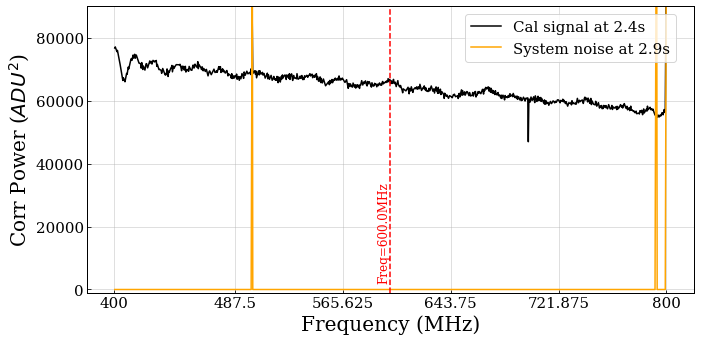

In [12]:
## for publication purpose -- plotting single time bin across the 400-800MHz band 

colorsarr=cm.gnuplot2(np.linspace(0,1,1024))
fig= plt.figure(figsize=[10,5])
ax = plt.subplot(111)
k=400
tb_on=57
tb_off=69

freq_arr=[512]

ax.plot(pow_mag[tb_on,:,0], c='black', label='Cal signal at 2.4s') 
ax.plot(pow_mag[tb_off,:,0], c='orange', label='System noise at 2.9s')
ax.set_xticks([0,200,400,600,800,1024],[800,721.875,643.75,565.625,487.5,400])
ax.invert_xaxis()
ax.set_ylim(-1000,90000)
#ax.set_title("time bin {} (on) and {} (off) -- 0x0".format(tb_on, tb_off))
ax.set_xlabel('Frequency (MHz)', fontsize=20)
ax.set_ylabel('Corr Power ($ADU^2$)', fontsize=20)
for freq in freq_arr:
    x=400+(1024-freq)*0.390625
    plt.axvline(freq, color='r', linestyle='--')
    plt.text(
    freq, 2000, f'Freq={x}MHz', rotation=90,
    #transform=ax.get_yaxis_transform(), 
    ha='right', va='bottom', fontsize=12,
    color='r'
)
plt.legend(loc='lower left', bbox_to_anchor=(0.61, 0.78))

#plt.suptitle(f"freq spectrum of single time index")
plt.tight_layout()

#fig.savefig('/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/March12...036Z/publication_figures/amplitudeI_at2.4and2.9sec.pdf', 
#            dpi=300)


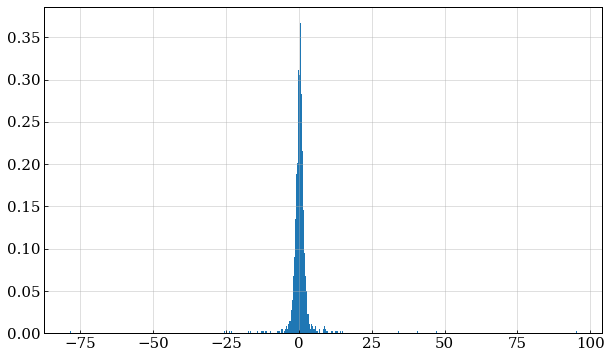

In [13]:
## getting original signal distribution
mag=np.sqrt(pow_mag[tb_on,:,1])
Xk=mag*np.exp(1j*pow_phase[tb_on,:,1])

x_time=np.fft.ifft(Xk)
x_time=np.asarray(x_time).real

plt.figure(figsize=(10,6))
plt.hist(x_time, bins=500, density=True, linewidth=1.5)
plt.show()

In [14]:
from scipy.stats import kurtosis

k_excess=kurtosis(x_time, fisher=True, bias=True)
k_pearson=kurtosis(x_time,fisher=False, bias=True)

print("Excess kurtosis:", k_excess)
print("Pearson kurtosis:", k_pearson)

Excess kurtosis: 171.22109974466542
Pearson kurtosis: 174.22109974466542


In [16]:
def cm_to_discrete(base_cmap, N):
    base = plt.cm.get_cmap(base_cmap)   # or pass a colormap instance
    colors = base(np.linspace(0, 1, N))
    return ListedColormap(colors)

In [28]:
colorz = cm_to_discrete(cm.gnuplot2, 10)

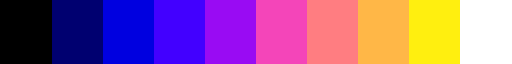

In [29]:
colorz

In [36]:
freq=400+((1024-512)*0.390625)
freq

600.0

## Bench test final plot 

0 100
4.194304 0.0


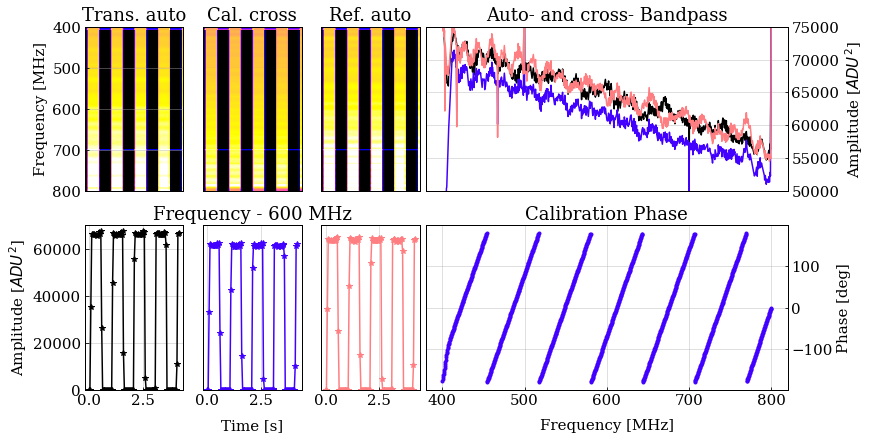

In [47]:


# plot, use gridspec

# upper right is waterfall
# lower right is time stream
# upper left is bandpass
# lower left is phase

from matplotlib.colors import ListedColormap

def cm_to_discrete(base_cmap, N):
    base = plt.cm.get_cmap(base_cmap)   # or pass a colormap instance
    colors = base(np.linspace(0, 1, N))
    return ListedColormap(colors)

fig = plt.figure(constrained_layout=True,figsize=(12,6))

gs = gridspec.GridSpec(3, 4, height_ratios=[0.49,0.49,0.005], width_ratios=[0.15,0.15,0.15,0.55],figure=fig)
ax0 = fig.add_subplot(gs[0, 0]) # upper left
ax1 = fig.add_subplot(gs[0, 1]) # upper next
ax2 = fig.add_subplot(gs[0, 2]) # upper next
ax3 = fig.add_subplot(gs[0, 3]) # upper right

ax4 = fig.add_subplot(gs[1, 0]) # lower left
ax5 = fig.add_subplot(gs[1, 1]) # lower next
ax6 = fig.add_subplot(gs[1, 2]) # lower next
ax7 = fig.add_subplot(gs[1,3]) # lower right
labax1 = fig.add_subplot(gs[2,0:3]) # xlabel
labax2 = fig.add_subplot(gs[2,3]) # xlabel
#cbax = fig.add_subplot(gs[0:1,1]) # colorbar
#eax = fig.add_subplot(gs[0:1,1]) # empty axis to center things



f_ind = 512 #600MHz 
t_ind = 57 # on
tb_off=69 # off
delta_time = np.diff(corr_data.time["irigb_time"])[1]*1e-9
tmin,tmax=[0,100]
xtime=np.linspace(0,delta_time*tmax, tmax)
print(tmin,tmax)
y_min, y_max = 400, 800
x_min, x_max = xtime[-1], xtime[0]
print(x_min,x_max)
colorz = cm_to_discrete(cm.gnuplot2, 10)

vmin = 0
vmax = 70000

# plot things in the right places
freqs=np.linspace(800,400,1024)


ax0.imshow(corr_data.vis[tmin:tmax,:,corr_indices[0]].real.T,vmin=vmin,vmax=vmax,cmap='gnuplot2', aspect='auto',
           extent=[x_max, x_min, y_max, y_min])
ax1.imshow(np.abs(corr_data.vis[tmin:tmax,:,corr_indices[1]].T),vmin=vmin,vmax=vmax,cmap='gnuplot2', aspect='auto',
           extent=[x_max, x_min, y_max, y_min])
ax2.imshow(corr_data.vis[tmin:tmax,:,corr_indices[2]].real.T,vmin=vmin,vmax=vmax,cmap='gnuplot2', aspect='auto',
           extent=[x_max, x_min, y_max, y_min])

ax3.plot(freqs,pow_mag[t_ind,:,0], color=colorz(0),label='Trans auto-correlation ON')
ax3.plot(freqs,pow_mag[t_ind,:,1], color=colorz(3),label='Cal cross-correlation ON')
ax3.plot(freqs,pow_mag[t_ind,:,4], color=colorz(6),label='Ref auto-correlation ON')


ax4.plot(xtime,pow_mag[tmin:tmax,f_ind,corr_indices[0]], marker="*",color=colorz(0))
ax5.plot(xtime,pow_mag[tmin:tmax,f_ind,corr_indices[1]], marker="*",color=colorz(3))
ax6.plot(xtime,pow_mag[tmin:tmax,f_ind,corr_indices[2]], marker="*",color=colorz(6))

ax7.plot(freqs,pow_phase[t_ind,:,corr_indices[1]],marker='.',linestyle='None',color=colorz(3))

## Now do all the fussy labelling
ax0.set_ylabel('Frequency [MHz]')
ax0.set_title('Trans. auto')
ax0.set_xticks([])

ax1.set_yticks([])
ax1.set_title('Cal. cross')
ax1.set_xticks([])

ax2.set_yticks([])
ax2.set_xticks([])
ax2.set_title('Ref. auto')

ax3.set_title('Auto- and cross- Bandpass')
#ax3.legend()
ax3.set_ylim(50000,75000)
ax3.set_xticks([])
ax3.yaxis.tick_right()
ax3.yaxis.set_label_position("right")
ax3.set_ylabel('Amplitude [$ADU^2$]')

ax4.set_ylabel(r'Amplitude [$ADU^2$]')
ax4.set_ylim(vmin,vmax)

ax5.set_yticks([])
ax5.set_ylim(vmin,vmax)
ax5.set_title('Frequency - 600 MHz')

ax6.set_yticks([])
ax6.set_ylim(vmin,vmax)



ax7.set_title('Calibration Phase')
#ax3.legend()
ax7.yaxis.tick_right()
ax7.yaxis.set_label_position("right")
ax7.set_ylabel('Phase [deg]')



labax1.set_xticks([])
labax1.set_yticks([])
labax1.set_frame_on(False)
labax1.set_xlabel('Time [s]')
labax2.set_xticks([])
labax2.set_yticks([])
labax2.set_frame_on(False)
labax2.set_xlabel('Frequency [MHz]')

plt.savefig('/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/March12...036Z/publication_figures/bench_test_4plots.png', 
            dpi=300)
plt.show()